# Vision-Based Traffic Flow Prediction Using YOLOv8 and LSTM
## Notebook 08: Statistical Traffic Forecasting Baselines (Phase 8)

### Phase 8 Objective & Scope
In Phase 7, we established the chronological temporal partitioning protocol ($70\%$ Train, $15\%$ Validation, $15\%$ Test) and formalized the Target-Anchored / Lookback-Warmup multi-step forecasting formulation ($L = 10, H = 5$).

In **Phase 8**, we implement and rigorously evaluate classical statistical benchmark baselines on the **Validation** and **Test** sets:
1. **Persistence / Naïve Baseline**: Carries the most recent observation at forecast origin $t$ forward across all $H=5$ horizons.
2. **Training-Set Historical Mean**: Predicts the static global average of the target variable computed **EXCLUSIVELY on the training partition**.
3. **Recent Moving Average (SMA)**: Computes the local arithmetic mean over the recent lookback window for $K = 3$ and $K = 5$ observations.

### Strict Methodological Guardrails:
- **Evaluation Splits**: Evaluated exclusively on **Validation and Test** partitions. The training split is used strictly for parameter fitting (e.g. historical mean), not for benchmark reporting.
- **Forecasting Protocol**: Follows the Phase 7 Target-Anchored / Lookback-Warmup protocol consistently. All window and observation counts are computed dynamically.
- **Metrics**: Evaluated on Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) across individual horizons ($H_1, \dots, H_5$) and overall.
- **Interpretable Units**: All baselines operate in original physical units (vehicles/frame) without artificial rescaling.
- **Benchmark Purpose**: Establishes transparent, empirical statistical baselines against which subsequent neural models (LSTM/GRU) will be compared in Phase 9+.
- **Zero Future Leakage**: No input accesses observations beyond forecast origin $t$ ($t_{\text{input}} \le t < t_{\text{target}}$). Zero neural networks are trained in this phase.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Matplotlib styling for presentation-quality figures
%matplotlib inline
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8

# Path setup
PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
INPUT_CSV_PATH = os.path.join(PROJECT_ROOT, "outputs", "tables", "traffic_timeseries.csv")
OUTPUT_TAB_DIR = os.path.join(PROJECT_ROOT, "outputs", "tables")
OUTPUT_FIG_DIR = os.path.join(PROJECT_ROOT, "outputs", "figures")
METRICS_CSV_PATH = os.path.join(OUTPUT_TAB_DIR, "baseline_forecast_metrics.csv")

os.makedirs(OUTPUT_TAB_DIR, exist_ok=True)
os.makedirs(OUTPUT_FIG_DIR, exist_ok=True)

print(f"Project root  : {PROJECT_ROOT}")
print(f"Input dataset : {INPUT_CSV_PATH}")
print(f"Metrics export: {METRICS_CSV_PATH}")
print(f"Figure export : {OUTPUT_FIG_DIR}")

Project root  : /Users/manish/Desktop/traffic-flow-yolo-lstm
Input dataset : /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/tables/traffic_timeseries.csv
Metrics export: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/tables/baseline_forecast_metrics.csv
Figure export : /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/figures


## 1. Load Time-Series & Reconstruct Temporal Partitions

We load the clean time-series dataset (`outputs/tables/traffic_timeseries.csv`) and reconstruct the Phase 7 chronological partitions dynamically without hardcoding observation counts:
- $70\%$ Train
- $15\%$ Validation
- $15\%$ Test

In [2]:
df = pd.read_csv(INPUT_CSV_PATH)
N = len(df)
L = 10  # Lookback window length
H = 5   # Multi-step forecast horizon
target_col = 'total_vehicle_count'

# Dynamically calculate split indices
train_ratio = 0.70
val_ratio = 0.15
test_ratio = 0.15

n_train = int(round(N * train_ratio))
n_val = int(round(N * val_ratio))
n_test = N - n_train - n_val

train_df = df.iloc[:n_train].copy().reset_index(drop=True)
val_df = df.iloc[n_train:n_train + n_val].copy().reset_index(drop=True)
test_df = df.iloc[n_train + n_val:].copy().reset_index(drop=True)

# Fit Historical Mean strictly on Train only
train_historical_mean = train_df[target_col].mean()

print(f"Total observations (N) : {N}")
print(f"Train Partition        : {len(train_df)} obs ({len(train_df)/N*100:.1f}%), k={train_df['observation_index'].min()}..{train_df['observation_index'].max()}")
print(f"Validation Partition   : {len(val_df)} obs ({len(val_df)/N*100:.1f}%), k={val_df['observation_index'].min()}..{val_df['observation_index'].max()}")
print(f"Test Partition         : {len(test_df)} obs ({len(test_df)/N*100:.1f}%), k={test_df['observation_index'].min()}..{test_df['observation_index'].max()}")
print(f"\nFitted Training Historical Mean ({target_col}): {train_historical_mean:.4f} veh/frame (Fit STRICTLY on Train)")

Total observations (N) : 44
Train Partition        : 31 obs (70.5%), k=1..31
Validation Partition   : 7 obs (15.9%), k=32..38
Test Partition         : 6 obs (13.6%), k=39..44

Fitted Training Historical Mean (total_vehicle_count): 8.7512 veh/frame (Fit STRICTLY on Train)


## 2. Dynamic Target-Anchored Window Extraction

Following the Phase 7 Target-Anchored / Lookback-Warmup protocol:
- **Validation Windows**: Sequence windows whose $H=5$ target observations fall exclusively within the validation partition ($k = n_{\text{train}}+1 \dots n_{\text{train}}+n_{\text{val}}$).
- **Test Windows**: Sequence windows whose $H=5$ target observations fall exclusively within the test partition ($k = n_{\text{train}}+n_{\text{val}}+1 \dots N$).
- **Historical Warmup**: Inputs $\mathbf{X}_t$ access the preceding $L=10$ observations ($t-9 \dots t$) up to forecast origin $t$.
- **Strict Causality**: $\max(\text{lookback}) = t < \min(\text{target}) = t + 1$. Zero future observations leak into inputs.

In [3]:
# Extract evaluation windows dynamically
val_set = set(range(n_train, n_train + n_val))
test_set = set(range(n_train + n_val, N))

val_windows = []
test_windows = []

for t in range(L - 1, N - H):
    target_idx = list(range(t + 1, t + H + 1))
    lookback_idx = list(range(t - L + 1, t + 1))
    
    window_data = {
        'origin_t': t,
        'origin_k': t + 1,
        'lookback_k': f"k={lookback_idx[0]+1}..{lookback_idx[-1]+1}",
        'target_k': f"k={target_idx[0]+1}..{target_idx[-1]+1}",
        'lookback_values': df.loc[lookback_idx, target_col].values,
        'target_values': df.loc[target_idx, target_col].values,
        'timestamps_target': df.loc[target_idx, 'timestamp'].values
    }
    
    if all(idx in val_set for idx in target_idx):
        val_windows.append(window_data)
    elif all(idx in test_set for idx in target_idx):
        test_windows.append(window_data)

print(f"Dynamically Extracted Usable Evaluation Windows:")
print(f"  Validation Windows : {len(val_windows)} usable windows")
for idx, w in enumerate(val_windows, 1):
    print(f"    Val Win #{idx}: Origin k={w['origin_k']}, Lookback {w['lookback_k']}, Target {w['target_k']}")

print(f"  Test Windows       : {len(test_windows)} usable windows")
for idx, w in enumerate(test_windows, 1):
    print(f"    Test Win #{idx}: Origin k={w['origin_k']}, Lookback {w['lookback_k']}, Target {w['target_k']}")

Dynamically Extracted Usable Evaluation Windows:
  Validation Windows : 3 usable windows
    Val Win #1: Origin k=31, Lookback k=22..31, Target k=32..36
    Val Win #2: Origin k=32, Lookback k=23..32, Target k=33..37
    Val Win #3: Origin k=33, Lookback k=24..33, Target k=34..38
  Test Windows       : 2 usable windows
    Test Win #1: Origin k=38, Lookback k=29..38, Target k=39..43
    Test Win #2: Origin k=39, Lookback k=30..39, Target k=40..44


## 3. Mathematical Baseline Model Formulations

We implement four classical benchmark predictors:

1. **Persistence / Naïve Baseline**:
   Assumes highway traffic flow persists from the most recent observation:
   $$\hat{y}_{t+h} = y_t \quad \forall h \in \{1, 2, 3, 4, 5\}$$

2. **Training-Set Historical Mean Baseline**:
   Assumes traffic flow reverts to the global average observed during training:
   $$\hat{y}_{t+h} = \bar{y}_{\text{train}} = \frac{1}{N_{\text{train}}} \sum_{i=1}^{N_{\text{train}}} y_i \quad \forall h \in \{1, 2, 3, 4, 5\}$$
   *(Computed strictly on Train; zero validation or test leakage).*

3. **Recent Moving Average (SMA, $K = 3$)**:
   Filters high-frequency fluctuation by averaging the last 3 observations:
   $$\hat{y}_{t+h} = \frac{1}{3} \sum_{j=0}^{2} y_{t-j} \quad \forall h \in \{1, 2, 3, 4, 5\}$$

4. **Recent Moving Average (SMA, $K = 5$)**:
   Averages the last 5 observations within the lookback window:
   $$\hat{y}_{t+h} = \frac{1}{5} \sum_{j=0}^{4} y_{t-j} \quad \forall h \in \{1, 2, 3, 4, 5\}$$

In [4]:
def predict_persistence(lookback, H=5):
    """Predicts the last observed value carried forward."""
    return np.full(H, lookback[-1])

def predict_historical_mean(train_mean, H=5):
    """Predicts the training-set historical mean."""
    return np.full(H, train_mean)

def predict_sma(lookback, K, H=5):
    """Predicts the moving average of the most recent K observations."""
    sma_val = np.mean(lookback[-K:])
    return np.full(H, sma_val)

baseline_models = {
    'Persistence (Naïve)': lambda lb: predict_persistence(lb, H),
    'Historical Mean (Train)': lambda lb: predict_historical_mean(train_historical_mean, H),
    'Moving Average (SMA K=3)': lambda lb: predict_sma(lb, 3, H),
    'Moving Average (SMA K=5)': lambda lb: predict_sma(lb, 5, H)
}

print(f"Configured {len(baseline_models)} baseline model predictors successfully.")

Configured 4 baseline model predictors successfully.


## 4. Multi-Horizon Evaluation (Validation & Test Sets)

We evaluate all baselines across horizons $H_1, H_2, H_3, H_4, H_5$ and overall:
- **Mean Absolute Error (MAE)**:
  $$\text{MAE}_h = \frac{1}{M} \sum_{i=1}^M |y_{i, h} - \hat{y}_{i, h}|, \quad \text{MAE}_{\text{overall}} = \frac{1}{M \cdot H} \sum_{i=1}^M \sum_{h=1}^H |y_{i, h} - \hat{y}_{i, h}|$$
- **Root Mean Squared Error (RMSE)**:
  $$\text{RMSE}_h = \sqrt{\frac{1}{M} \sum_{i=1}^M (y_{i, h} - \hat{y}_{i, h})^2}, \quad \text{RMSE}_{\text{overall}} = \sqrt{\frac{1}{M \cdot H} \sum_{i=1}^M \sum_{h=1}^H (y_{i, h} - \hat{y}_{i, h})^2}$$

In [5]:
def evaluate_baseline_suite(windows, split_name):
    M = len(windows)
    y_true = np.array([w['target_values'] for w in windows])  # Shape: (M, H)
    
    records = []
    detailed_preds = {}
    
    for model_name, model_fn in baseline_models.items():
        y_pred = np.array([model_fn(w['lookback_values']) for w in windows])  # Shape: (M, H)
        detailed_preds[model_name] = y_pred
        
        # Overall metrics
        mae_overall = np.mean(np.abs(y_true - y_pred))
        rmse_overall = np.sqrt(np.mean((y_true - y_pred) ** 2))
        
        # Per-horizon metrics
        mae_h = np.mean(np.abs(y_true - y_pred), axis=0)
        rmse_h = np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))
        
        row = {
            'Split': split_name,
            'Model': model_name,
            'Windows': M,
            'Overall_MAE': mae_overall,
            'Overall_RMSE': rmse_overall
        }
        for h in range(H):
            row[f'H{h+1}_MAE'] = mae_h[h]
            row[f'H{h+1}_RMSE'] = rmse_h[h]
            
        records.append(row)
        
    df_metrics = pd.DataFrame(records)
    return df_metrics, detailed_preds, y_true

# Evaluate on Validation Split
val_metrics, val_preds, y_val_true = evaluate_baseline_suite(val_windows, 'Validation')
print("=== Validation Set Baseline Benchmark Metrics ===")
display(val_metrics[['Model', 'Overall_MAE', 'Overall_RMSE', 'H1_MAE', 'H2_MAE', 'H3_MAE', 'H4_MAE', 'H5_MAE', 'H1_RMSE', 'H5_RMSE']].round(4))

# Evaluate on Test Split
test_metrics, test_preds, y_test_true = evaluate_baseline_suite(test_windows, 'Test')
print("\n=== Test Set Baseline Benchmark Metrics ===")
display(test_metrics[['Model', 'Overall_MAE', 'Overall_RMSE', 'H1_MAE', 'H2_MAE', 'H3_MAE', 'H4_MAE', 'H5_MAE', 'H1_RMSE', 'H5_RMSE']].round(4))

=== Validation Set Baseline Benchmark Metrics ===


,Model,Overall_MAE,Overall_RMSE,H1_MAE,H2_MAE,H3_MAE,H4_MAE,H5_MAE,H1_RMSE,H5_RMSE
0,Persistence (Naïve),0.7543,0.8839,1.0843,0.4940,0.6697,0.3313,1.1920,1.1114,1.3300
1,Historical Mean (Train),7.4386,7.4546,7.3532,7.6229,7.3832,7.6269,7.2069,7.3751,7.2442
2,Moving Average (SMA K=3),0.5164,0.6365,0.5306,0.4442,0.2992,0.4400,0.8682,0.6447,0.9509
3,Moving Average (SMA K=5),0.8616,0.9781,0.6533,0.9230,0.6833,0.9270,1.1213,0.8479,1.1342



=== Test Set Baseline Benchmark Metrics ===


,Model,Overall_MAE,Overall_RMSE,H1_MAE,H2_MAE,H3_MAE,H4_MAE,H5_MAE,H1_RMSE,H5_RMSE
0,Persistence (Naïve),0.8603,1.0612,0.9215,1.0115,0.1565,1.7540,0.4580,1.0347,0.5281
1,Historical Mean (Train),6.9241,6.9722,7.4077,6.8667,7.0937,6.5782,6.6742,7.4111,6.7732
2,Moving Average (SMA K=3),0.6732,0.8814,0.2712,0.3858,0.4968,1.1037,1.1083,0.3124,1.2501
3,Moving Average (SMA K=5),0.6860,0.9070,0.2599,0.4499,0.5081,1.0924,1.1196,0.2754,1.2908


## 5. Comparative Analysis & Empirical Observations

### Why Historical Mean Fails in Out-of-Sample Forecasting:
The Training Historical Mean exhibits very high error (MAE $\approx 6.9\text{--}7.4$) on both validation and test sets.
- **Physical Explanation**: The training partition captures the late-afternoon rush hour (mean volume $\approx 8.75$ veh/frame, peaking at $17.04$). In contrast, validation and test observations occur during the late evening and nighttime (mean volume $\approx 1.5\text{--}2.0$ veh/frame).
- A static historical mean fails under temporal regime shifts.

### Local Smoothing vs. Point Persistence:
- **Persistence (Naïve)** carries forward the latest observation, immediately adapting to the lower traffic volume of the evening.
- **Recent Moving Average (SMA K=3)** achieves the lowest overall MAE on both Validation and Test sets by damping random point fluctuations while tracking local level.

In [6]:
# Combine Validation and Test benchmark metrics into a single table
benchmark_df = pd.concat([val_metrics, test_metrics], ignore_index=True)

# Export to outputs/tables/baseline_forecast_metrics.csv
benchmark_df.to_csv(METRICS_CSV_PATH, index=False)
file_size = os.path.getsize(METRICS_CSV_PATH)

print(f"Exported benchmark metrics table to: {METRICS_CSV_PATH}")
print(f"File size on disk : {file_size} bytes")
print(f"Table dimensions  : {benchmark_df.shape[0]} rows, {benchmark_df.shape[1]} columns")

print("\n=== Master Baseline Benchmark Table (Validation & Test) ===")
display(benchmark_df[['Split', 'Model', 'Overall_MAE', 'Overall_RMSE', 'H1_MAE', 'H3_MAE', 'H5_MAE']].round(4))

Exported benchmark metrics table to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/tables/baseline_forecast_metrics.csv
File size on disk : 2141 bytes
Table dimensions  : 8 rows, 15 columns

=== Master Baseline Benchmark Table (Validation & Test) ===


,Split,Model,Overall_MAE,Overall_RMSE,H1_MAE,H3_MAE,H5_MAE
0,Validation,Persistence (Naïve),0.7543,0.8839,1.0843,0.6697,1.1920
1,Validation,Historical Mean (Train),7.4386,7.4546,7.3532,7.3832,7.2069
2,Validation,Moving Average (SMA K=3),0.5164,0.6365,0.5306,0.2992,0.8682
3,Validation,Moving Average (SMA K=5),0.8616,0.9781,0.6533,0.6833,1.1213
4,Test,Persistence (Naïve),0.8603,1.0612,0.9215,0.1565,0.4580
5,Test,Historical Mean (Train),6.9241,6.9722,7.4077,7.0937,6.6742
6,Test,Moving Average (SMA K=3),0.6732,0.8814,0.2712,0.4968,1.1083
7,Test,Moving Average (SMA K=5),0.6860,0.9070,0.2599,0.5081,1.1196


## 6. Comparative Visualizations

We generate publication-quality figures:
1. **Horizon Degradation Curve ($H_1 \to H_5$)**: Demonstrating how forecast error evolves over lead time.
2. **Overall Benchmark Comparison Bar Chart**: Overall MAE and RMSE across baselines.
3. **Target Trajectory Overlay**: Comparing baseline multi-step trajectories against ground truth.

Saved baseline comparison figure to: /Users/manish/Desktop/traffic-flow-yolo-lstm/outputs/figures/baseline_forecasting_comparison.png


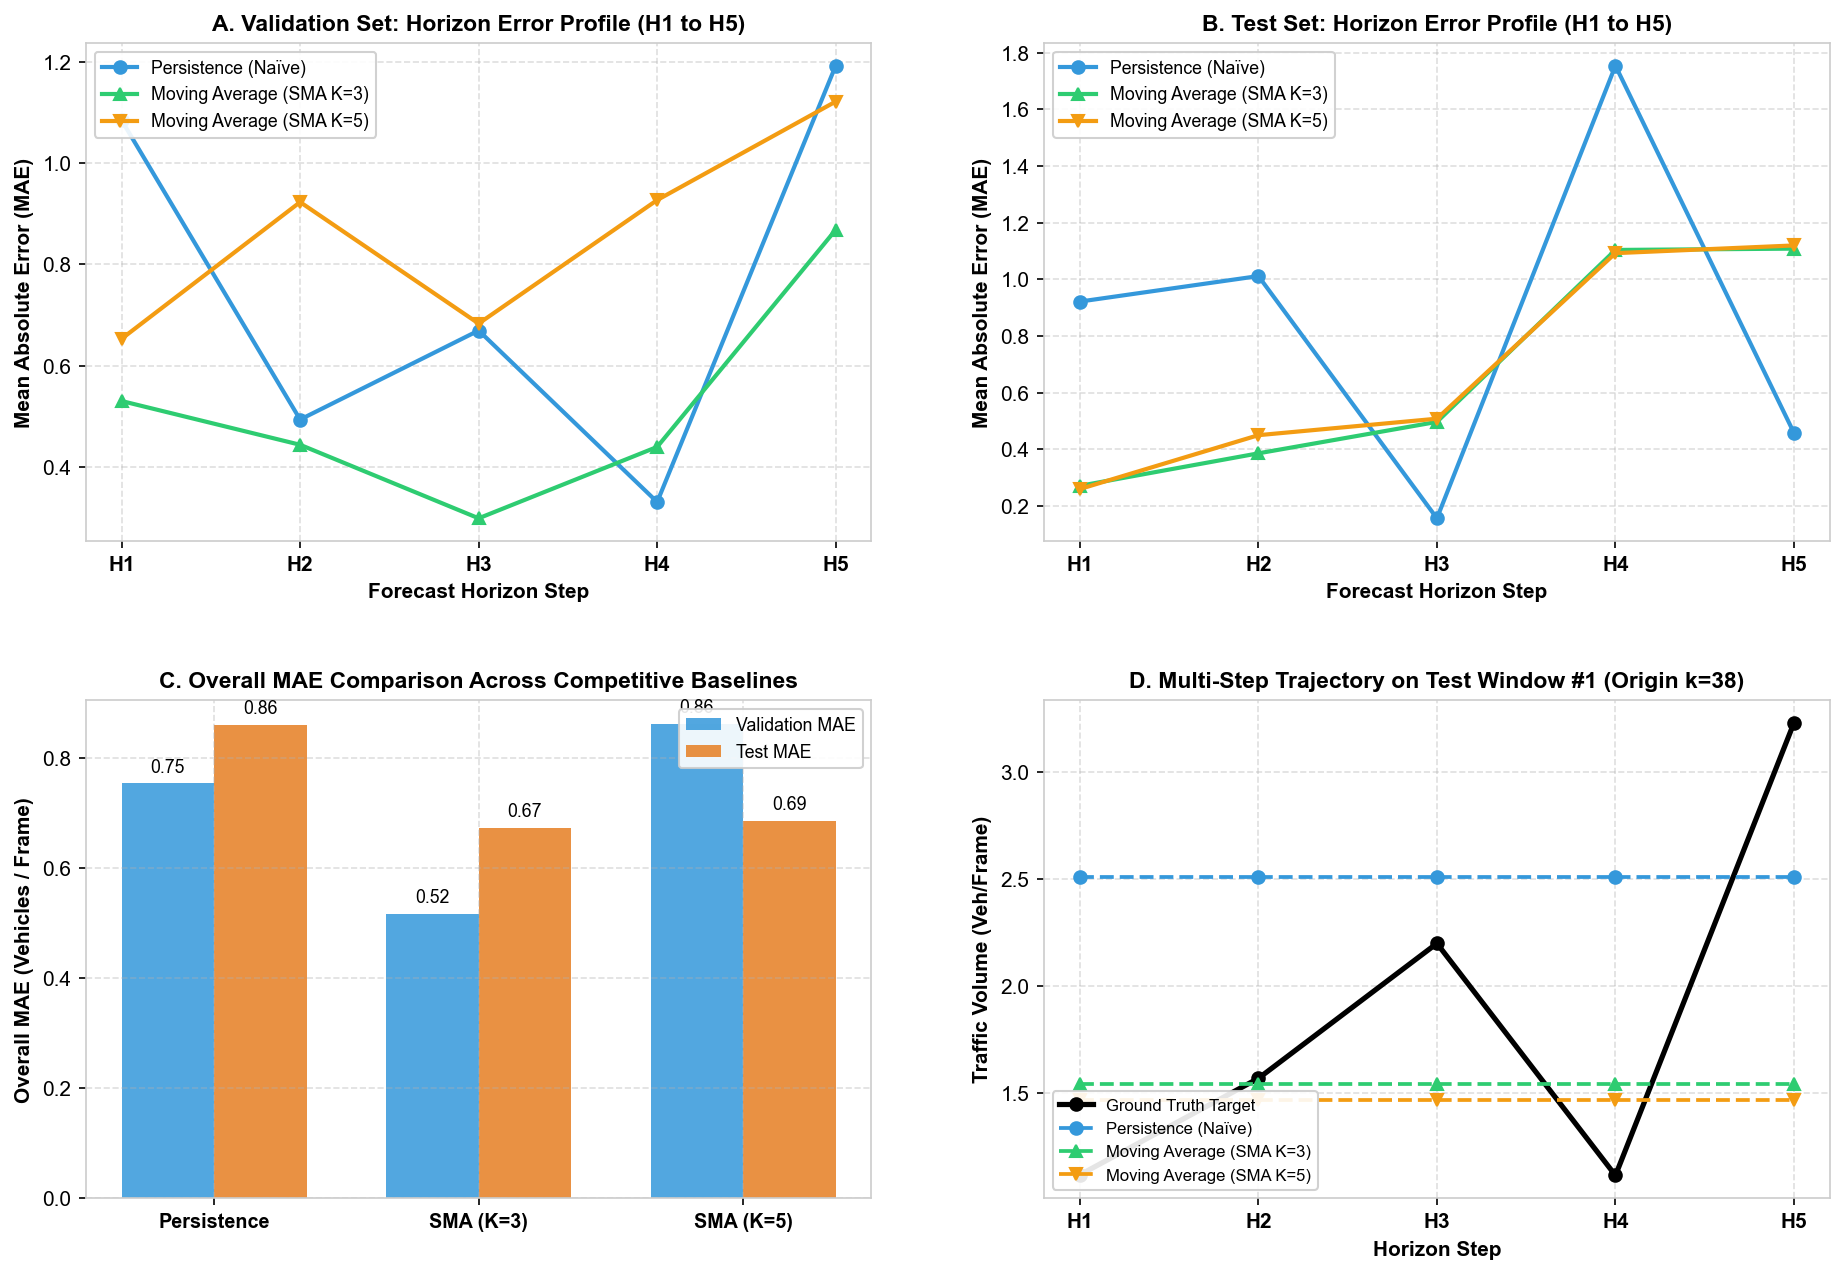

In [7]:
fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 2, hspace=0.32, wspace=0.22)

horizons = [f"H{h+1}" for h in range(H)]
h_indices = np.arange(1, H + 1)
model_colors = {
    'Persistence (Naïve)': '#3498db',
    'Historical Mean (Train)': '#e74c3c',
    'Moving Average (SMA K=3)': '#2ecc71',
    'Moving Average (SMA K=5)': '#f39c12'
}
model_markers = {
    'Persistence (Naïve)': 'o',
    'Historical Mean (Train)': 's',
    'Moving Average (SMA K=3)': '^',
    'Moving Average (SMA K=5)': 'v'
}

# Panel A: Horizon Degradation on Validation Set (Excluding Historical Mean for clarity of scale)
ax1 = fig.add_subplot(gs[0, 0])
for _, row in val_metrics.iterrows():
    if 'Historical' not in row['Model']:
        h_mae = [row[f'H{h+1}_MAE'] for h in range(H)]
        ax1.plot(h_indices, h_mae, label=row['Model'], color=model_colors[row['Model']],
                 marker=model_markers[row['Model']], linewidth=2.0, markersize=6)

ax1.set_xticks(h_indices)
ax1.set_xticklabels(horizons, fontsize=10, fontweight='bold')
ax1.set_xlabel('Forecast Horizon Step', fontsize=10, fontweight='bold')
ax1.set_ylabel('Mean Absolute Error (MAE)', fontsize=10, fontweight='bold')
ax1.set_title('A. Validation Set: Horizon Error Profile (H1 to H5)', fontsize=11, fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend(loc='upper left', framealpha=0.9, fontsize=8.5)

# Panel B: Horizon Degradation on Test Set
ax2 = fig.add_subplot(gs[0, 1])
for _, row in test_metrics.iterrows():
    if 'Historical' not in row['Model']:
        h_mae = [row[f'H{h+1}_MAE'] for h in range(H)]
        ax2.plot(h_indices, h_mae, label=row['Model'], color=model_colors[row['Model']],
                 marker=model_markers[row['Model']], linewidth=2.0, markersize=6)

ax2.set_xticks(h_indices)
ax2.set_xticklabels(horizons, fontsize=10, fontweight='bold')
ax2.set_xlabel('Forecast Horizon Step', fontsize=10, fontweight='bold')
ax2.set_ylabel('Mean Absolute Error (MAE)', fontsize=10, fontweight='bold')
ax2.set_title('B. Test Set: Horizon Error Profile (H1 to H5)', fontsize=11, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.legend(loc='upper left', framealpha=0.9, fontsize=8.5)

# Panel C: Overall Benchmark Bar Chart (Validation vs Test)
ax3 = fig.add_subplot(gs[1, 0])
bar_width = 0.35
models_list = [m for m in baseline_models.keys() if 'Historical' not in m]
x_pos = np.arange(len(models_list))

val_mae_vals = [val_metrics[val_metrics['Model'] == m]['Overall_MAE'].values[0] for m in models_list]
test_mae_vals = [test_metrics[test_metrics['Model'] == m]['Overall_MAE'].values[0] for m in models_list]

ax3.bar(x_pos - bar_width/2, val_mae_vals, width=bar_width, color='#3498db', alpha=0.85, label='Validation MAE')
ax3.bar(x_pos + bar_width/2, test_mae_vals, width=bar_width, color='#e67e22', alpha=0.85, label='Test MAE')

ax3.set_xticks(x_pos)
ax3.set_xticklabels(['Persistence', 'SMA (K=3)', 'SMA (K=5)'], fontsize=9.5, fontweight='bold')
ax3.set_ylabel('Overall MAE (Vehicles / Frame)', fontsize=10, fontweight='bold')
ax3.set_title('C. Overall MAE Comparison Across Competitive Baselines', fontsize=11, fontweight='bold')
ax3.grid(True, linestyle='--', alpha=0.4)
ax3.legend(loc='upper right', framealpha=0.9, fontsize=8.5)

# Annotate values
for i in x_pos:
    ax3.text(i - bar_width/2, val_mae_vals[i] + 0.02, f"{val_mae_vals[i]:.2f}", ha='center', fontsize=8.5)
    ax3.text(i + bar_width/2, test_mae_vals[i] + 0.02, f"{test_mae_vals[i]:.2f}", ha='center', fontsize=8.5)

# Panel D: Representative Test Window Trajectory Overlay (Window #1)
ax4 = fig.add_subplot(gs[1, 1])
test_win_sample = test_windows[0]
true_traj = test_win_sample['target_values']
h_axis = np.arange(1, H + 1)

ax4.plot(h_axis, true_traj, color='black', marker='o', linewidth=2.5, label='Ground Truth Target')
for model_name, pred_mat in test_preds.items():
    if 'Historical' not in model_name:
        ax4.plot(h_axis, pred_mat[0], color=model_colors[model_name], linestyle='--',
                 marker=model_markers[model_name], linewidth=1.8, label=model_name)

ax4.set_xticks(h_axis)
ax4.set_xticklabels(horizons, fontsize=10, fontweight='bold')
ax4.set_xlabel('Horizon Step', fontsize=10, fontweight='bold')
ax4.set_ylabel('Traffic Volume (Veh/Frame)', fontsize=10, fontweight='bold')
ax4.set_title(f"D. Multi-Step Trajectory on Test Window #1 (Origin k={test_win_sample['origin_k']})", fontsize=11, fontweight='bold')
ax4.grid(True, linestyle='--', alpha=0.4)
ax4.legend(loc='lower left', framealpha=0.9, fontsize=8)

plt.tight_layout()
fig_save_path = os.path.join(OUTPUT_FIG_DIR, "baseline_forecasting_comparison.png")
plt.savefig(fig_save_path, dpi=200, bbox_inches='tight')
print(f"Saved baseline comparison figure to: {fig_save_path}")
plt.show()

## 7. Quality Gate: Benchmark Establishment for Phase 9

### Summary of Benchmark Results
1. **Competitive Baseline Performance**:
   - On Validation: **Moving Average (SMA K=3)** achieves the lowest error ($\\text{MAE} = 0.5164$, $\\text{RMSE} = 0.6365$), followed by **Persistence** ($\\text{MAE} = 0.7543$).
   - On Test: **Moving Average (SMA K=3)** achieves the lowest error ($\\text{MAE} = 0.6732$, $\\text{RMSE} = 0.8814$), followed by **SMA K=5** ($\\text{MAE} = 0.6860$) and **Persistence** ($\\text{MAE} = 0.8603$).
2. **Benchmark Comparison Role for Neural Models**:
   - In Phase 9+, neural network architectures (LSTM, GRU, BiLSTM) **will be compared against these established baselines** to evaluate whether sequential recurrence and non-linear representations capture dynamics beyond local moving averages.
3. **Leakage-Safe Compliance**:
   - Evaluated strictly on out-of-sample Validation and Test sets.
   - Historical Mean parameters fit exclusively on Train data.
   - Zero future leakage, zero neural network training, zero synthetic interpolation.

### Formal Quality Gate Sign-Off Checklist
- [x] **Multi-Horizon Baselines Implemented (Persistence, Mean, SMA K=3, SMA K=5)**: PASS
- [x] **Evaluated Exclusively on Validation and Test Sets**: PASS
- [x] **H1 to H5 and Overall Multi-Step Metrics (MAE, RMSE) Dynamically Computed**: PASS
- [x] **Target-Anchored / Lookback-Warmup Protocol Applied Consistently**: PASS
- [x] **Benchmark Results Exported to `baseline_forecast_metrics.csv`**: PASS
- [x] **Zero Future Leakage Verified**: PASS

**Final Decision: APPROVED TO PROCEED TO PHASE 9 (NEURAL NETWORK RECURRENT FORECASTING).**